In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
x_train = np.array([1.0 , 2.0])
y_train = np.array([100.0 , 300.0])

In [16]:
print(x_train.shape)
m = x_train.shape[0]

(2,)


In [17]:
for i in range(m):
  print(f"x^{i}: {x_train[i]} , y^{i}: {y_train[i]}")


x^0: 1.0 , y^0: 100.0
x^1: 2.0 , y^1: 300.0


In [18]:
def compute_model_output(x,w,b):
  m = x.shape[0]
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb[i] = w * x[i] + b
  return f_wb

In [19]:
w = 70
b = 70

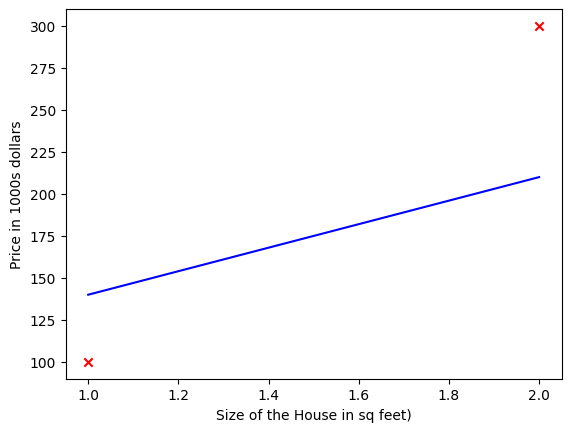

In [20]:
tmp_f_wb = compute_model_output(x_train , w, b)
plt.plot(x_train, tmp_f_wb , c = 'b', label= "Model Predictions")
plt.scatter(x_train, y_train, c='r' , label = "Actual Data" , marker='x')
plt.xlabel("Size of the House in sq feet)")
plt.ylabel("Price in 1000s dollars")
plt.show()

In [21]:
# This is not ap optimal solution. so , how to fit the line.?
def compute_cost(x,y,w,b):
  m = x.shape[0]
  total_cost = 0
  for i in range(m):
    f_wb = w * x[i] + b
    cost = (f_wb - y[i]) ** 2
    total_cost = total_cost + cost
  new_cost = 1 / (2 * m) * total_cost
  return new_cost

In [22]:
calculate_cost = compute_cost(x_train, y_train, w, b)
print(calculate_cost)

2425.0


In [23]:
def compute_gradient(x,y,w,b):
  dj_dw = 0
  dj_db = 0
  m = x.shape[0]
  for i in range(m):
    f_wb = w * x[i] + b
    dj_dw_i = (f_wb - y[i]) * x[i]
    dj_db_i = f_wb - y[i]
    dj_dw += dj_dw_i
    dj_db += dj_db_i

  dj_dw = (1/ m) * dj_dw
  dj_db = (1/m) * dj_db

  return dj_dw , dj_db

In [25]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iterations, cost_function, gradient_function):
  w = w_in
  b = b_in
  j_history = []
  p_history = []


  for i in range(num_iterations):

    dj_dw , dj_db = gradient_function(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i < 10000:
      j_history.append(cost_function(x,y,w,b))
      p_history.append([w,b])
    return w , b, j_history, p_history


In [30]:
w_in = 0
b_in = 0
iters = 10000
tmp_alpha = 1.0e-2

w_final, b_final, jw_history, p_history = gradient_descent(x_train, y_train, w_in, b_in, tmp_alpha, iters, compute_cost, compute_gradient)

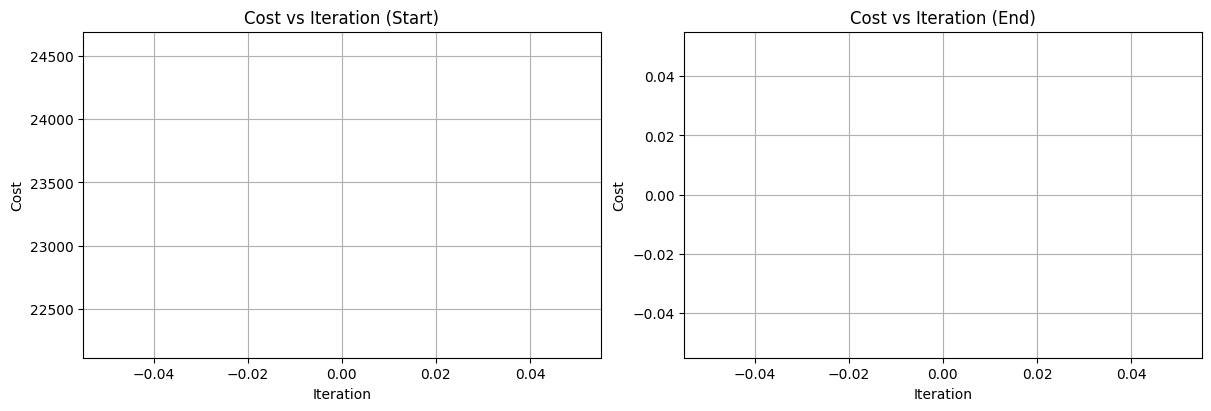

In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4), constrained_layout=True)

# First 100 iterations
ax1.plot(jw_history[:100])
ax1.set_title("Cost vs Iteration (Start)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Cost")
ax1.grid(True)

# From iteration 1000 onward
ax2.plot(
    1000 + np.arange(len(jw_history[1000:])),
    jw_history[1000:]
)
ax2.set_title("Cost vs Iteration (End)")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Cost")
ax2.grid(True)

plt.show()

In [ ]:
w_in = 0
b_in = 0
iters = 10000
tmp_alpha = 1.0e-2

w_final, b_final, jw_history, p_history = gradient_descent(x_train, y_train, w_in, b_in, tmp_alpha, iters, compute_cost, compute_gradient)
print(f"f(w,b) found by the gradient descent are: w:{w_final:8.4f} and b:{b_final:8.4f}")

In [ ]:
w = 199.9323
b = -99.8904

In [ ]:
predictions = compute_model_output(x_train, y_train, w, b)
print(predictions)

plt.scatter(x_train, y_train, c='r' , marker = "x" , label = "actual values")
plt.plot(x_train, predictions , c= 'b' , label = "Model Prediction")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()